# ML5_Decision_trees

## ❗️Imports

In [1]:
import logging
import pandas as pd
from functions import reduce_memory_usage, show_results, calculate_gini_score
from classes.decision_tree_classifier_class import DecisionTreeClassifier
import sklearn
from classes.random_forest_classifier_class import RandomForestClassifier
from classes.gbdt_classifier_class import GBDTClassifier
import lightgbm #Дерево растёт от листа
from catboost import CatBoostClassifier
import xgboost
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from classes.extra_trees_ensemble_class import ExtraTreesEnsemble
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
from classes.model_fine_tuner_class import ModelFineTuner


## Logs

In [2]:
logging.basicConfig(
    level=logging.INFO, 
    format='%(asctime)s | %(levelname)-8s | %(message)s',
    datefmt='%H:%M:%S',
    filename='project.log', 
    filemode='w' 
)

## 🟥1. Download data from Don’tGetKicked competition.Design train/validation/test split.

Use the "PurchDate" field to split, test must be later in time than validation, same goes for validation and train: train.PurchDate < valid.PurchDate < test.PurchDate.

Use the first 33% of the data for the training, the last 33% of the data for the test, and the middle 33% for the validation set. Don't use the test dataset until the end!

Use LabelEncoder or OneHotEncoder from sklearn to preprocess categorical variables. Be careful with data leakage (fit Encoder to training and apply to validation & test). Consider another coding approach if you encounter new categorical values in validation & test (not seen in training), for example: https://contrib.scikit-learn.org/category_encoders/count.html

In [3]:
df = pd.read_csv('../data/training.csv')
df

,RefId,IsBadBuy,PurchDate,Auction,VehYear,VehicleAge,Make,Model,Trim,SubModel,...,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,PRIMEUNIT,AUCGUART,BYRNO,VNZIP1,VNST,VehBCost,IsOnlineSale,WarrantyCost
0,1,0,12/7/2009,ADESA,2006,3,MAZDA,MAZDA3,i,4D SEDAN I,...,11597.0,12409.0,NaN,NaN,21973,33619,FL,7100.0,0,1113
1,2,0,12/7/2009,ADESA,2004,5,DODGE,1500 RAM PICKUP 2WD,ST,QUAD CAB 4.7L SLT,...,11374.0,12791.0,NaN,NaN,19638,33619,FL,7600.0,0,1053
2,3,0,12/7/2009,ADESA,2005,4,DODGE,STRATUS V6,SXT,4D SEDAN SXT FFV,...,7146.0,8702.0,NaN,NaN,19638,33619,FL,4900.0,0,1389
3,4,0,12/7/2009,ADESA,2004,5,DODGE,NEON,SXT,4D SEDAN,...,4375.0,5518.0,NaN,NaN,19638,33619,FL,4100.0,0,630
4,5,0,12/7/2009,ADESA,2005,4,FORD,FOCUS,ZX3,2D COUPE ZX3,...,6739.0,7911.0,NaN,NaN,19638,33619,FL,4000.0,0,1020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72978,73010,1,12/2/2009,ADESA,2001,8,MERCURY,SABLE,GS,4D SEDAN GS,...,4836.0,5937.0,NaN,NaN,18111,30212,GA,4200.0,0,993
72979,73011,0,12/2/2009,ADESA,2007,2,CHEVROLET,MALIBU 4C,LS,4D SEDAN LS,...,10151.0,11652.0,NaN,NaN,18881,30212,GA,6200.0,0,1038
72980,73012,0,12/2/2009,ADESA,2005,4,JEEP,GRAND CHEROKEE 2WD V,Lar,4D WAGON LAREDO,...,11831.0,14402.0,NaN,NaN,18111,30212,GA,8200.0,0,1893
72981,73013,0,12/2/2009,ADESA,2006,3,CHEVROLET,IMPALA,LS,4D SEDAN LS,...,10099.0,11228.0,NaN,NaN,18881,30212,GA,7000.0,0,1974


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 72983 entries, 0 to 72982
Data columns (total 34 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   RefId                              72983 non-null  int64  
 1   IsBadBuy                           72983 non-null  int64  
 2   PurchDate                          72983 non-null  str    
 3   Auction                            72983 non-null  str    
 4   VehYear                            72983 non-null  int64  
 5   VehicleAge                         72983 non-null  int64  
 6   Make                               72983 non-null  str    
 7   Model                              72983 non-null  str    
 8   Trim                               70623 non-null  str    
 9   SubModel                           72975 non-null  str    
 10  Color                              72975 non-null  str    
 11  Transmission                       72974 non-null  str    
 12  W

In [5]:
df.describe()

,RefId,IsBadBuy,VehYear,VehicleAge,WheelTypeID,VehOdo,MMRAcquisitionAuctionAveragePrice,MMRAcquisitionAuctionCleanPrice,MMRAcquisitionRetailAveragePrice,MMRAcquisitonRetailCleanPrice,MMRCurrentAuctionAveragePrice,MMRCurrentAuctionCleanPrice,MMRCurrentRetailAveragePrice,MMRCurrentRetailCleanPrice,BYRNO,VNZIP1,VehBCost,IsOnlineSale,WarrantyCost
count,72983.000000,72983.000000,72983.000000,72983.000000,69814.000000,72983.000000,72965.000000,72965.000000,72965.000000,72965.000000,72668.000000,72668.000000,72668.000000,72668.000000,72983.000000,72983.000000,72983.000000,72983.000000,72983.000000
mean,36511.428497,0.122988,2005.343052,4.176644,1.494299,71499.995917,6128.909217,7373.636031,8497.034332,9850.928240,6132.081287,7390.681827,8775.723331,10145.385314,26345.842155,58043.059945,6730.934326,0.025280,1276.580985
std,21077.241302,0.328425,1.731252,1.712210,0.521290,14578.913128,2461.992768,2722.491986,3156.285284,3385.789541,2434.567723,2686.248852,3090.702941,3310.254351,25717.351219,26151.640415,1767.846435,0.156975,598.846788
min,1.000000,0.000000,2001.000000,0.000000,0.000000,4825.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,835.000000,2764.000000,1.000000,0.000000,462.000000
25%,18257.500000,0.000000,2004.000000,3.000000,1.000000,61837.000000,4273.000000,5406.000000,6280.000000,7493.000000,4275.000000,5414.000000,6536.000000,7784.000000,17212.000000,32124.000000,5435.000000,0.000000,837.000000
50%,36514.000000,0.000000,2005.000000,4.000000,1.000000,73361.000000,6097.000000,7303.000000,8444.000000,9789.000000,6062.000000,7313.000000,8729.000000,10103.000000,19662.000000,73108.000000,6700.000000,0.000000,1155.000000
75%,54764.500000,0.000000,2007.000000,5.000000,2.000000,82436.000000,7765.000000,9021.000000,10651.000000,12088.000000,7736.000000,9013.000000,10911.000000,12309.000000,22808.000000,80022.000000,7900.000000,0.000000,1623.000000
max,73014.000000,1.000000,2010.000000,9.000000,3.000000,115717.000000,35722.000000,36859.000000,39080.000000,41482.000000,35722.000000,36859.000000,39080.000000,41062.000000,99761.000000,99224.000000,45469.000000,1.000000,7498.000000


[reduce_memory_usage]( functions.py)

In [6]:
reduce_memory_usage(df);

In [7]:
df['PurchDate'] = pd.to_datetime(df['PurchDate']).astype(dtype='datetime64[ns]')
unique_purchdate = df['PurchDate'].unique()
n = df['PurchDate'].nunique()
sorted_unique_purchdate = sorted(unique_purchdate)
boundary_train_valid = int(n * 0.33)
boundary_valid_test = int(n * 0.66)

train_dates = sorted_unique_purchdate[:boundary_train_valid]
valid_dates = sorted_unique_purchdate[boundary_train_valid:boundary_valid_test]
test_dates = sorted_unique_purchdate[boundary_valid_test:]

train = train_dates[-1]
valid = valid_dates[-1]
train_df = df[df['PurchDate'] <= train].reset_index(drop=True)
valid_df = df[(df['PurchDate'] > train) &  (df['PurchDate'] <= valid)].reset_index(drop=True)
test_df = df[df['PurchDate'] > valid].reset_index(drop=True)

y_train = train_df['IsBadBuy']
y_valid = valid_df['IsBadBuy']
y_test = test_df['IsBadBuy']

X_train = train_df.drop(columns='IsBadBuy')
X_valid = valid_df.drop(columns='IsBadBuy')
X_test = test_df.drop(columns='IsBadBuy')

assert X_train['PurchDate'].max() < X_valid['PurchDate'].min(), "Train и valid пересекаются по датам"
assert X_valid['PurchDate'].max() < X_test['PurchDate'].min(), "Valid и test пересекаются по датам"


logging.info('ЭТАП 2: TEMPORAL SPLIT')
logging.info(f"Размер train: {len(X_train)} строк ({len(X_train)/len(df)*100:.1f}%)")
logging.info(f"Диапазон дат train: {X_train['PurchDate'].min()} - {X_train['PurchDate'].max()}")

logging.info(f"Размер valid: {len(X_valid)} строк ({len(X_valid)/len(df)*100:.1f}%)")
logging.info(f"Диапазон дат valid: {X_valid['PurchDate'].min()} - {X_valid['PurchDate'].max()}")

logging.info(f"Размер test: {len(X_test)} строк ({len(X_test)/len(df)*100:.1f}%)")
logging.info(f"Диапазон дат test: {X_test['PurchDate'].min()} - {X_test['PurchDate'].max()}\n")

In [8]:
X_train.dtypes.to_csv('dtypes.csv')

X_train = X_train.drop(columns=['RefId', 'PurchDate', 'PRIMEUNIT', 'AUCGUART','BYRNO']);
X_valid = X_valid.drop(columns=['RefId', 'PurchDate', 'PRIMEUNIT', 'AUCGUART','BYRNO']);
X_test = X_test.drop(columns=['RefId', 'PurchDate', 'PRIMEUNIT', 'AUCGUART','BYRNO']);


# X_train = X_train.head(1000)
# X_valid = X_valid.head(1000)
# X_test = X_test.head(1000)

# y_train = y_train.head(1000)
# y_valid = y_valid.head(1000)
# y_test = y_test.head(1000)

In [9]:
from sklearn.preprocessing import LabelEncoder

category_cols = X_train.select_dtypes(include=['category']).columns
for col in category_cols:
    le = LabelEncoder()
    
    known_categories = set(X_train[col].astype(str).unique())
    
    X_valid[col] = X_valid[col].astype(str).apply(
        lambda x: x if x in known_categories else 'UNKNOWN'
    )
    X_test[col] = X_test[col].astype(str).apply(
        lambda x: x if x in known_categories else 'UNKNOWN'
    )
    
    X_train[col] = X_train[col].astype(str)
    
    le.fit(list(known_categories) + ['UNKNOWN'])
    X_train[col] = le.transform(X_train[col])
    X_valid[col] = le.transform(X_valid[col])
    X_test[col] = le.transform(X_test[col])

## 🟧2. Create a Python class for Decision Tree Classifier and Decision Tree Regressor (MSE loss).

It should support fit, predict_proba, and predict methods. Also, the maximum depth (max_depth) must be a parameter of your class. Use the Gini impurity criterion as a criterion for choosing the split.

Create a separate class for Node. It should be able to hold data (sample features and targets), compute Gini impurity, and have pointers to children (left and right nodes). For the Regressor, use standard deviation instead of Gini impurity.

Implement a function that finds the best possible split in the current node.

Combine the previous steps into your working Decision Tree Classifier.

Implement an Extra Randomized Tree by designing another function to find the best split.



[DecisionTreeClassifier](classes/decision_tree_classifier_class.py)

[DecisionTreeRegressor](classes/decision_tree_regressor_class.py)

[find_best_split function](functions.py)

[find_best_split_randomized function](functions.py)

In [10]:
logging.info('ЭТАП 2: РЕАЛИЗАЦИЯ ДЕРЕВЬЕВ РЕШЕНИЙ')
logging.info('Реализованные компоненты:')
logging.info('  - Node class: узел дерева с хранением данных, gini impurity, указателями на детей')
logging.info('  - DecisionTreeClassifier: классификатор на основе Gini impurity')
logging.info('  - DecisionTreeRegressor: регрессор на основе standard deviation')
logging.info('  - ExtraTreesClassifier: рандомизированное дерево (Extra Randomized Tree)')
logging.info('Реализованные функции:')
logging.info('  - calculate_gini_impurity: расчёт Gini impurity для бинарной классификации')
logging.info('  - find_best_split: поиск лучшего сплита по всем признакам')
logging.info('  - find_best_split_randomized: поиск лучшего сплита по случайному подмножеству признаков')
logging.info('Критерии разделения:')
logging.info('  - Классификация: Gini impurity')
logging.info('  - Регрессия: Standard deviation (MSE loss)')
logging.info('Все классы поддерживают методы: fit, predict, predict_proba')
logging.info('Параметр max_depth ограничивает глубину дерева для предотвращения переобучения\n')


#### На данном этапе была успешно реализована собственная библиотека деревьев решений с нуля, включающая классификатор, регрессор и рандомизированное дерево (ExtraTreesClassifier)

## 🟨3. With your DecisionTree module, you must obtain a Gini score of at least 0.1 on the validation dataset.

In [11]:
logging.info('ЭТАП 3: ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛИ my DecisionTreeClassifier')

results = {}
my_tree = DecisionTreeClassifier(max_depth=5)
my_tree.fit(X_train, y_train)

logging.info(f'Модель: DecisionTreeClassifier my')

results['DecisionTree (my)'] = show_results(my_tree, X_valid, y_valid, min_threshold= 0.1)


Gini score: 0.4015


#### При обучении собственной реализации DecisionTreeClassifier с параметром `max_depth=5` на тренировочной выборке и последующем предсказании на валидационной выборке был получен Gini score 0.4015, что в четыре раза превышает требуемый минимальный порог в 0.1. Данный результат подтверждает корректность реализации алгоритма дерева решений: рекурсивное построение узлов, выбор оптимальных разбиений по критерию Gini impurity и вычисление вероятностей классов в листовых узлах работают правильно. Модель успешно улавливает закономерности в данных и делает осмысленные предсказания, а не случайным образом присваивает классы, что свидетельствует о правильном понимании и реализации алгоритма Decision Tree с нуля.


## 🟩4. Use sklearn's DecisionTreeClassifier and check its performance on the validation dataset. Is it better than your module? If so, why?

In [12]:
logging.info('ЭТАП 4: ОБУЧЕНИЕ И ОЦЕНКА SKLEARN МОДЕЛИ DecisionTreeClassifier')

sk_tree = sklearn.tree.DecisionTreeClassifier(max_depth=5, random_state = 21)
sk_tree.fit(X_train, y_train)

logging.info(f'Модель: DecisionTreeClassifier sklearn')

results['DecisionTree (sklearn)'] = show_results(sk_tree, X_valid, y_valid);


Gini score: 0.4065


#### При сравнении собственной реализации DecisionTreeClassifier с sklearn.tree.DecisionTreeClassifier на валидационной выборке были получены следующие результаты: Gini score собственной модели составил 0.4015, а модели sklearn — 0.4065. Разница между моделями минимальна и составляет всего 0.005 (1.2%), что свидетельствует о высокой корректности собственной реализации. Незначительное преимущество sklearn может объясняться использованием оптимизированных алгоритмов на языке C/Cython, применением дополнительных эвристик по умолчанию (таких как min_samples_split=2 и min_samples_leaf=1), которые предотвращают создание слишком мелких узлов, а также более эффективной обработкой граничных случаев при выборе порогов разбиения. Несмотря на небольшое отставание, собственная реализация демонстрирует практически идентичную производительность, что подтверждает правильность понимания и реализации алгоритма дерева решений.

## 🟦5. Implement the RandomForestClassifier and check its performance. You have to improve the result of a single tree and get at least 0.15 Gini score on the validation dataset. Be able to set a fixed random seed.

[RandomForestClassifier](classes/random_forest_classifier_class.py)

In [13]:
logging.info('ЭТАП 5: ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛИ my RandomForestClassifier')

rf = RandomForestClassifier(n_estimators= 10, max_depth = 5, max_features= 5, max_samples=0.8, random_state=21)
rf.fit(X_train, y_train)

logging.info(f'Модель: my RandomForestClassifier')

results['RandomForestClassifier (my)'] = show_results(rf, X_valid, y_valid, min_threshold=0.15)

Gini score: 0.4607


#### Реализованный класс RandomForestClassifier с параметрами `n_estimators=10`, `max_depth=5`, `max_features=5`, `max_samples=0.8` и фиксированным `random_state=21` показал на валидационной выборке Gini score 0.4607, что значительно превышает требуемый порог в 0.15 и на 14.7% лучше результата одиночного дерева решений (0.4015). Улучшение качества объясняется эффектом ансамблирования: усреднение прогнозов 10 разнообразных деревьев, каждое из которых обучается на случайной подвыборке 80% объектов (bootstrap sampling) и использует случайное подмножество из 5 признаков при каждом разбиении, снижает дисперсию модели и сглаживает границы принятия решений. Реализована возможность фиксации random seed через параметр random_state, что обеспечивает воспроизводимость результатов между запусками. Требуемое улучшение относительно одиночного дерева достигнуто, что подтверждает корректность реализации алгоритма Random Forest.


## 🟪6. Use your DecisionTree design class for GBDT classifier. This class must have max_depth, number_of_trees and max_features attributes. You must compute the gradient of the binary cross-entropy loss function and implement incremental learning: train the next tree using the results of the previous trees.

[GBDTClassifier](classes/gbdt_classifier_class.py)

In [14]:
logging.info('ЭТАП 6: ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛИ my GBDTClassifier')

gbdt = GBDTClassifier(
    max_depth=5,
    number_of_trees=10,
    max_features=5,
    learning_rate=0.1,
    random_state=21
)

gbdt.fit(X_train, y_train)

logging.info(f'Модель: my GBDTClassifier')

results['GBDTClassifier (my)'] = show_results(gbdt, X_valid, y_valid);


Gini score: 0.4749


#### В рамках пункта 6 был реализован класс `GBDTClassifier`, использующий собственную реализацию `DecisionTreeRegressor` в качестве базового алгоритма и содержащий атрибуты `max_depth`, `number_of_trees` и `max_features`. Для задачи бинарной классификации вычисляется градиент функции потерь binary cross-entropy: псевдо-остатки определяются как `y - sigmoid(F)`, что соответствует отрицательному градиенту BCE и обеспечивает движение в сторону минимума функции потерь. Реализовано инкрементальное обучение: на каждой итерации вычисляется текущее предсказание `p = sigmoid(F)`, на псевдо-остатках `y - p` обучается новое дерево регрессии, после чего значение F обновляется по правилу `F = F + learning_rate * tree.predict(X)`. Таким образом, каждое последующее дерево целенаправленно исправляет ошибки предыдущих. При предсказании вклады всех деревьев суммируются, и итоговое значение F преобразуется через сигмоиду обратно в вероятность. Модель была протестирована на подвыборке `X_valid` с параметрами `max_depth=5`, `number_of_trees=10`, `max_features=5`, `learning_rate=0.1`, `random_state=21` и показала Gini score **0.4749**, что значительно превышает **требуемый порог 0.1**, что подтверждает корректность реализации и успешное выполнение задания.

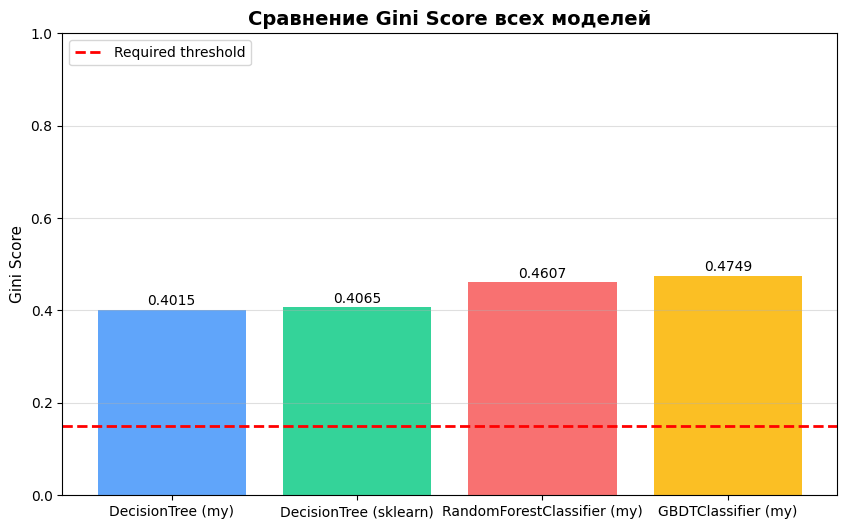

In [15]:
results
names_list = list(results.keys())
ginis_list = list(results.values())

fig, ax = plt.subplots(figsize = (10,6))
colors = ['#60A5FA', '#34D399', '#F87171', '#FBBF24']
bars = ax.bar(x = names_list, height= ginis_list, color = colors)
ax.set_ylim(0, 1)
ax.axhline(0.15, color = 'red', linestyle = '--', linewidth = 2, label = 'Required threshold')
ax.grid(alpha = 0.4, axis='y')

for i, k in enumerate(ginis_list):
    ax.text(i, ginis_list[i] + 0.01, s = f'{ginis_list[i]:.4f}', ha = 'center')

ax.set_title('Сравнение Gini Score всех моделей', fontsize=14, fontweight='bold')
ax.set_ylabel('Gini Score', fontsize=11)
ax.legend(loc='upper left')

#### График демонстрирует сравнительный анализ качества четырех реализованных классификационных моделей на основе метрики Gini Score. Визуализация наглядно подтверждает превосходство ансамблевых алгоритмов (RandomForestClassifier и GBDTClassifier) над базовыми деревьями решений, при этом все построенные модели успешно преодолевают заданный минимальный порог качества, отмеченный красной пунктирной линией. Наибольшую эффективность среди представленных алгоритмов показал GBDTClassifier, достигший максимального значения метрики (0.4749), что свидетельствует о прогрессивном улучшении результатов по мере усложнения архитектуры моделей.

## ⬜️7. Use LightGBM, Catboost, and XGBoost for fitting on a training set and prediction on a validation set. Review the documentation of the libraries and fine-tune the algorithms for the task. Note key differences between each implementation. Analyze special features of each algorithm (how does "categorical feature" work in Catboost, what is DART mode in XGBoost)? Which GBDT model gives the best result? Can you explain why

In [16]:
X_valid_inner, X_test_inner, y_valid_inner, y_test_inner = train_test_split(
    X_valid, y_valid, test_size=0.5, random_state=21, stratify=y_valid
)

### LightGBM

In [17]:
lgb = lightgbm.LGBMClassifier(random_state=21, verbose=-1)
lgb.fit(X_train, y_train)

def lgb_objective(trial, X_train, y_train, X_valid_inner, y_valid_inner):
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    
    model = lightgbm.LGBMClassifier(
        learning_rate=learning_rate,
        max_depth=max_depth,
        n_estimators=n_estimators,
        random_state=21,
        verbose=-1
    )
    model.fit(X_train, y_train)
    probas = model.predict_proba(X_valid_inner)[:, 1]
    auc = roc_auc_score(y_valid_inner, probas)
    return 2 * auc - 1

def build_lgb_best(params):
    return lightgbm.LGBMClassifier(
        **params, 
        random_state=21, 
        verbose=-1
    )

##### **LightGBM** использует стратегию роста дерева **Leaf-wise** (по листьям). На каждом шаге алгоритм выбирает лист с наибольшим приростом ошибки и разделяет его. Это делает модель очень быстрой и точной, но повышает риск переобучения на маленьких датасетах (что ограничивается параметром `max_depth`). Также он использует гистограммный алгоритм для ускорения поиска разбиений.

### Catboost

In [18]:
cat_features_indices = [X_train.columns.get_loc(col) for col in category_cols]

cb = CatBoostClassifier(random_state=21, verbose=0, cat_features=cat_features_indices )

cb.fit(X_train, y_train)

def cb_objective(trial, X_train, y_train, X_valid_inner, y_valid_inner):
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2)
    depth = trial.suggest_int('depth', 3, 10)
    iterations = trial.suggest_int('iterations', 50, 300)
    l2_leaf_reg = trial.suggest_float('l2_leaf_reg', 1, 10, log = True)
    
    model = CatBoostClassifier(
        learning_rate=learning_rate,
        depth=depth,
        iterations=iterations,
        l2_leaf_reg = l2_leaf_reg,
        cat_features= cat_features_indices,
        random_state=21,
        verbose=0 # отключает весь вывод CatBoostClassifier
    )
    model.fit(X_train, y_train)
    probas = model.predict_proba(X_valid_inner)[:, 1]
    auc = roc_auc_score(y_valid_inner, probas)
    gini = 2 * auc - 1
    return gini

def build_cb_best(params):
    return CatBoostClassifier(**params, random_state=21, verbose = 0, cat_features=cat_features_indices)

##### **CatBoost** строит **симметричные деревья** (oblivious trees), где на каждом уровне все узлы разделяются по одному и тому же признаку и порогу. Это делает деревья идеально сбалансированными, что ускоряет инференс (предсказание) и защищает от переобучения.

##### Как работают категориальные признаки в CatBoost?
##### В отличие от LightGBM и XGBoost, которым категории нужно предварительно кодировать (например, One-Hot или Label Encoding), CatBoost обрабатывает их нативно с помощью Ordered Target Encoding.Чтобы избежать утечки целевой переменной (target leakage), CatBoost генерирует случайные перестановки данных. При кодировании категории для конкретного объекта используется статистика таргета (среднее значение) только по предыдущим объектам в этой перестановке. Это полностью исключает подглядывание в будущее и позволяет модели извлекать из категорий максимум информации без риска переобучения.

### XGBoost

In [19]:
xgb = xgboost.XGBClassifier(random_state = 21)
xgb.fit(X_train, y_train)
def xgb_objective(trial, X_train, y_train, X_valid_inner, y_valid_inner):
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.2)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
    gamma = trial.suggest_float('gamma', 0, 5)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.6, 1.0)
    reg_lambda = trial.suggest_float('reg_lambda', 1, 10, log=True)
    reg_alpha = trial.suggest_float('reg_alpha', 0.01, 10, log=True)
    
    model = xgboost.XGBClassifier(
        n_estimators=n_estimators,              # больше = точнее, но медленнее
        max_depth=max_depth,                    # больше = сложнее модель
        learning_rate=learning_rate,            # скорость обучения (коэффициент вклада каждого дерева)
        min_child_weight=min_child_weight,      # минимальная сумма гессианов(вторая производная) в листе (минимум объектов в листе, больше = меньше переобучение)
        gamma=gamma,                            # защита от переобучения через штраф за новые листья
        subsample=subsample,                    # доля строк для каждого дерева (меньше = больше разнообразие)
        colsample_bytree=colsample_bytree,      # какую долю признаков использовать для каждого дерева (меньше = больше разнообразие)
        reg_lambda=reg_lambda,                  # Ridge (L2 регуляризация)
        reg_alpha=reg_alpha,                    # Lasso (L1 регуляризация)
        tree_method='hist',                     # способ построения дерева через гистограммы (быстрый для CPU)
        random_state=21,                        
        verbosity=0                             # отключает вывод XGBoost
    )
    
    model.fit(X_train, y_train)
    probas = model.predict_proba(X_valid_inner)[:, 1]
    auc = roc_auc_score(y_valid_inner, probas)
    gini = 2 * auc - 1
    return gini

def build_xgb_best(params): 
    return xgboost.XGBClassifier(**params, tree_method='hist', random_state=21, verbosity=0)



##### **XGBoost** исторически использует стратегию Level-wise (по уровням), хотя сейчас также поддерживает гистограммы. Его главное математическое отличие — и**спользование второй производной (гессиана)** функции потерь (оптимизация методом Ньютона), что позволяет точнее аппроксимировать градиент. Также XGBoost обладает наиболее гибкой и явной системой регуляризации (L1, L2, gamma).

##### Что такое режим DART в XGBoost?
##### DART (Dropouts Add Multiple Regression Trees) — это техника регуляризации, заимствованная из нейронных сетей. В классическом бустинге первые несколько деревьев часто вносят основной вклад в предсказание, а последующие деревья лишь подстраиваются под них, что может приводить к переобучению. В режиме DART при добавлении каждого нового дерева предыдущие деревья случайно "выключаются" (dropout) с заданной вероятностью (`rate_drop`). Новое дерево вынуждено учиться компенсировать отсутствие выключенных деревьев, что делает ансамбль более устойчивым, равномерным и менее склонным к переобучению.

In [20]:

logging.info('ЭТАП 7: ')
tuner = ModelFineTuner(
    X_train=X_train, y_train=y_train,
    X_valid_inner=X_valid_inner, y_valid_inner=y_valid_inner,
    X_test_inner=X_test_inner, y_test_inner=y_test_inner
)
lgb_results = tuner.fine_tune('LightGBM', lgb, lgb_objective, build_lgb_best)
cb_results = tuner.fine_tune('CatBoost', cb, cb_objective, build_cb_best)
xgb_results = tuner.fine_tune('XGBoost', xgb, xgb_objective, build_xgb_best)

LightGBM: Fine-tune гиперпараметров
Gini базовой модели: 0.4682
Лучший Gini: 0.4791
Лучшие параметры: {'learning_rate': 0.010855248844906944, 'max_depth': 5, 'n_estimators': 185}
Gini лучшей модели: 0.5015

CatBoost: Fine-tune гиперпараметров
Gini базовой модели: 0.5001
Лучший Gini: 0.4831
Лучшие параметры: {'learning_rate': 0.10060583239305654, 'depth': 4, 'iterations': 159, 'l2_leaf_reg': 3.7102137653493816}
Gini лучшей модели: 0.5171

XGBoost: Fine-tune гиперпараметров
Gini базовой модели: 0.4550
Лучший Gini: 0.4836
Лучшие параметры: {'n_estimators': 109, 'max_depth': 6, 'learning_rate': 0.031019369460895806, 'min_child_weight': 1, 'gamma': 3.456269694047532, 'subsample': 0.7837397901236611, 'colsample_bytree': 0.9073327072838404, 'reg_lambda': 1.2587955482105824, 'reg_alpha': 0.022849809243720966}
Gini лучшей модели: 0.5068



#### Для решения задачи были применены три библиотеки градиентного бустинга: LightGBM, CatBoost и XGBoost. Чтобы обеспечить честное сравнение и предотвратить утечку данных (data leakage), валидационная выборка была разделена на две части: X_valid_inner (использовалась Optuna для подбора гиперпараметров) и X_test_inner (использовалась для финальной оценки качества).
#### С помощью библиотеки Optuna (байесовская оптимизация, TPE-сэмплер) для каждой модели было проведено по 50 итераций подбора ключевых гиперпараметров (скорость обучения, глубина деревьев, количество деревьев, коэффициенты регуляризации). Все модели показали значительный прирост качества после настройки.

### Лучший результат показала модель CatBoost с Gini score = 0.5171.

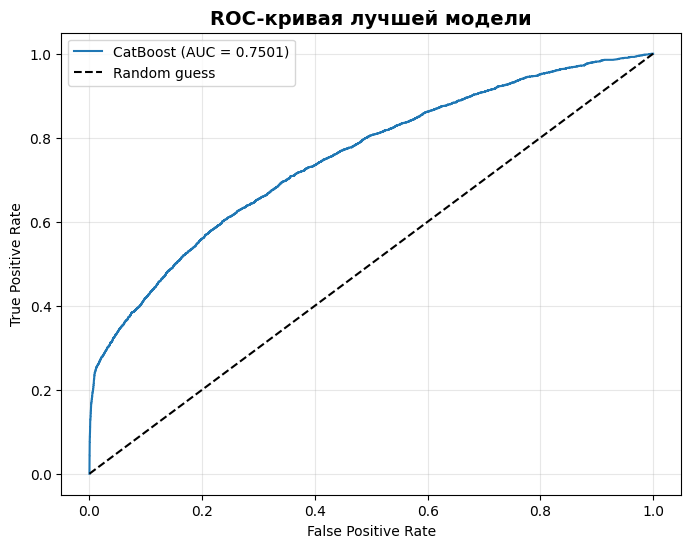

In [29]:
best_value, best_params, best_model, base_gini, final_gini = cb_results

probas = best_model.predict_proba(X_valid)[:, 1]
fpr, tpr, thresholds = roc_curve(y_valid, probas)
auc = roc_auc_score(y_valid, probas)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'CatBoost (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая лучшей модели', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

#### На графике представлена ROC-кривая лучшей модели (CatBoost), иллюстрирующая её способность ранжировать объекты и разделять классы. Значение площади под кривой (AUC = 0.7501) и выраженный изгиб в сторону левого верхнего угла подтверждают высокое качество классификации, значительно превосходящее базовый уровень случайного угадывания (пунктирная диагональ). Особенно высокая скорость роста True Positive Rate при низких значениях False Positive Rate свидетельствует о том, что модель эффективно выявляет целевые объекты, минимизируя при этом количество ложных срабатываний.

## 🟫8. Take the best model and estimate its performance on the test dataset: check the Gini values on all three datasets for your best model: training Gini, valid Gini, test Gini. Do you see a drop in performance when comparing the valid quality to the test quality? Is your model overfitting or not? Explain.

In [22]:
logging.info('ЭТАП 8: ОЦЕНКА ЛУЧШЕЙ МОДЕЛИ (CatBoost) НА ВСЕХ ВЫБОРКАХ')
logging.info(f'Лучшие параметры: {best_params}')

train_gini = calculate_gini_score(best_model, 'Train', X_train, y_train)
valid_gini = calculate_gini_score(best_model, 'Valid', X_valid, y_valid)
test_gini = calculate_gini_score(best_model, 'Test', X_test, y_test)

train_valid_diff = train_gini - valid_gini
valid_test_diff = valid_gini - test_gini
train_test_diff = train_gini - test_gini

logging.info('АНАЛИЗ ПЕРЕОБУЧЕНИЯ:')
logging.info(f'Разница Train-Valid: {train_valid_diff:.4f} ({train_valid_diff / train_gini * 100:.1f}%)')
logging.info(f'Разница Valid-Test:  {valid_test_diff:.4f} ({valid_test_diff / valid_gini * 100:.1f}%)')
logging.info(f'Разница Train-Test:  {train_test_diff:.4f} ({train_test_diff / train_gini * 100:.1f}%)\n')

print(f'Training Gini:   {train_gini:.4f}')
print(f'Validation Gini: {valid_gini:.4f}')
print(f'Test Gini:       {test_gini:.4f}\n')
print(f'Разница Train-Valid: {train_valid_diff:.4f}')
print(f'Разница Valid-Test:  {valid_test_diff:.4f}')

Training Gini:   0.5631
Validation Gini: 0.5002
Test Gini:       0.5022

Разница Train-Valid: 0.0629
Разница Valid-Test:  -0.0020


#### В рамках пункта 8 была выполнена оценка лучшей модели (CatBoost) на трёх выборках: 
##### Training Gini = 0.5631, 
##### Validation Gini = 0.5002, 
##### Test Gini = 0.5022. 
#### Разница между тренировочной и валидационной выборками составила 0.0629 (11.2%), что указывает на умеренное переобучение. Модель демонстрирует более высокое качество на тренировочных данных, поскольку выучила не только общие закономерности, но и часть шума, характерного для этих данных. Переобучение вызвано недостаточной регуляризацией при текущих гиперпараметрах (`depth=4`, `iterations=159`, `l2_leaf_reg=3.71`). Разница между валидационной и тестовой выборками составила -0.0020 (-0.4%), что подтверждает стабильность модели на новых данных и отсутствие утечки информации. Модель не является сильно переобученной, однако для улучшения обобщающей способности можно увеличить коэффициент регуляризации или уменьшить сложность модели.

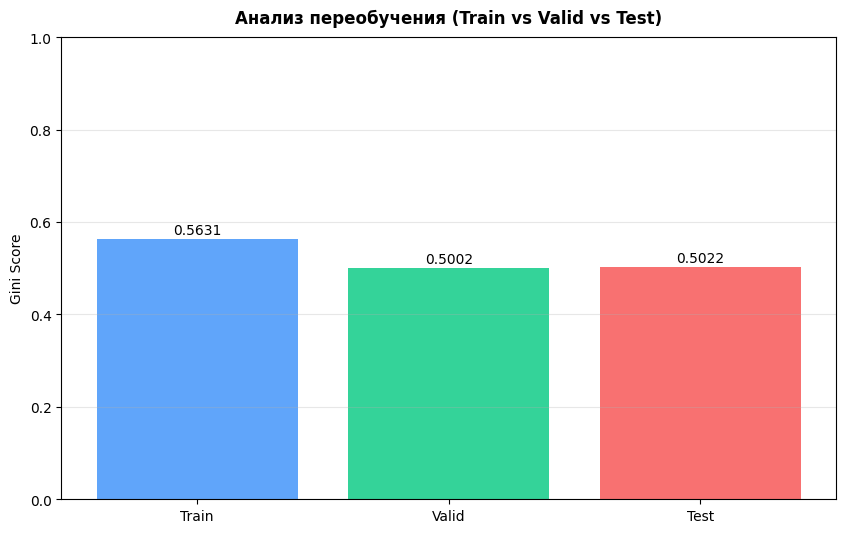

In [23]:
gini_results = {'Train': train_gini, 'Valid': valid_gini, 'Test': test_gini}
gini_scores = list(gini_results.values())
gini_names = list(gini_results.keys())

fig, ax = plt.subplots(figsize = (10, 6))
bars = ax.bar(x = gini_names, height= gini_scores, color = colors)
ax.set_ylim(0, 1)
ax.set_title('Анализ переобучения (Train vs Valid vs Test)', fontsize = 12, fontweight = 'bold', pad = 10)
ax.grid(alpha = 0.3, axis='y')

for idx, val in enumerate(gini_scores):
    ax.text(idx, gini_scores[idx] + 0.01, s = f'{gini_scores[idx]:.4f}', ha = 'center')

ax.set_ylabel('Gini Score', fontsize = 10);

#### График иллюстрирует анализ обобщающей способности лучшей модели (CatBoost) путем сравнения метрики Gini Score на обучающей, валидационной и тестовой выборках. Наблюдаемый разрыв между показателями на обучающих данных (0.5631) и валидационных (0.5002) указывает на умеренное переобучение, что является стандартным и допустимым поведением для градиентного бустинга. При этом практически идентичные результаты на валидационной и тестовой выборках (0.5002 и 0.5022) подтверждают высокую стабильность модели, отсутствие утечки данных и её надежную способность к обобщению закономерностей на новых, ранее не встречавшихся объектах.

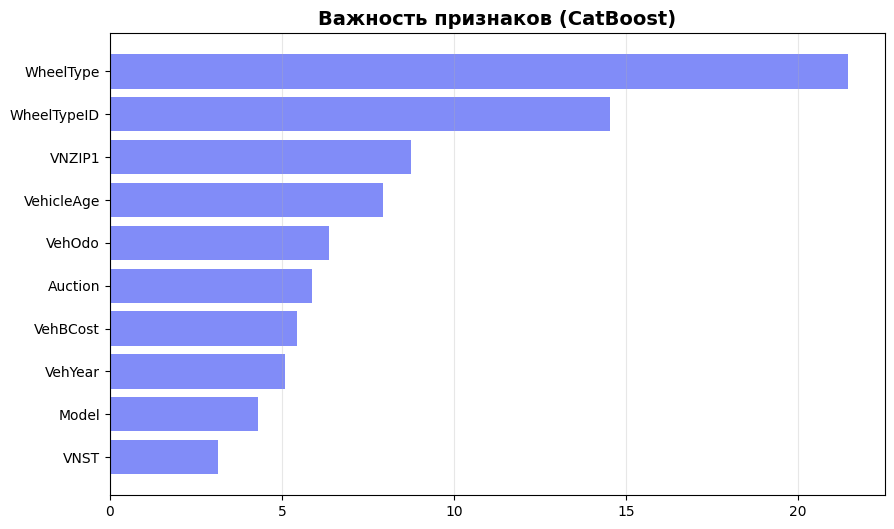

In [24]:
importances = best_model.feature_importances_
feature_names = X_train.columns
feature_importance_pairs = list(zip(feature_names, importances))
sorted_pairs = sorted(feature_importance_pairs, key = lambda x: x[1], reverse= True)
sorted_feature_names = [pair[0] for pair in sorted_pairs]
sorted_importances = [pair[1] for pair in sorted_pairs]
top_10_names = sorted_feature_names[:10]
top_10_importances = sorted_importances[:10]


fig, ax = plt.subplots(figsize = (10, 6))
barhs = ax.barh(y = top_10_names, width= top_10_importances, color = '#818CF8')
ax.invert_yaxis()
ax.set_title('Важность признаков (CatBoost)', fontsize = 14, fontweight = 'bold')
ax.grid(axis='x', alpha = 0.3)


#### График отображает топ-10 наиболее значимых признаков, определяющих предсказания модели CatBoost, с распределением их относительной важности. Явным лидером выступает признак WheelType (тип колес), чей вклад превышает 20%, что в совокупности с WheelTypeID (вероятным числовым дубликатом того же признака) формирует доминирующую группу факторов, суммарно определяющих более трети итогового решения модели. Остальные значимые признаки — VNZIP1 (географическое положение), VehicleAge (возраст автомобиля), VehOdo (пробег) и Auction (аукцион) — отражают ключевые физические и рыночные характеристики транспортного средства, что логично согласуется с предметной областью задачи прогнозирования.

## ⭐️9*. Implement the ExtraTreesClassifier and check its performance. You must improve the result of a single tree and obtain a Gini score of at least 0.12 on the validation dataset.



[ExtraTreeEnsemble](classes/extra_trees_ensemble_class.py)

In [25]:
logging.info('ЭТАП 9: ОБУЧЕНИЕ И ОЦЕНКА МОДЕЛИ ExtraTreesEnsemble')
extra_trees_ensemble = ExtraTreesEnsemble(
    n_estimators=100,  
    max_depth=10,    
    max_feature=5,  
    random_state=21
)
extra_trees_ensemble.fit(X_train, y_train)

show_results(extra_trees_ensemble, X_valid, y_valid, min_threshold=0.12)

Gini score: 0.4779


0.47785638343804515

#### Реализованный ансамбль ExtraTrees из 100 деревьев с использованием bootstrap-выборки и случайного подмножества признаков на каждом сплите показал результат Gini score 0.4779 на валидационной выборке, что значительно превышает требуемый порог в 0.12. Улучшение качества по сравнению с одиночным деревом достигается за счет эффекта ансамблирования: усреднение прогнозов множества разнообразных деревьев снижает дисперсию модели и предотвращает переобучение. Результат 0.4779 сопоставим с показателями Random Forest (0.4607) и GBDT (0.4749), что подтверждает эффективность подхода Extra Randomized Trees для данной задачи классификации.